In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

df_true = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "clmentbisaillon/fake-and-real-news-dataset",
    "True.csv"
)

df_fake = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "clmentbisaillon/fake-and-real-news-dataset",
    "Fake.csv"
)

print(df_true.shape)
print(df_fake.shape)
df_true.head()

/tmp/ipykernel_14860/1503801518.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_true = kagglehub.load_dataset(


Using Colab cache for faster access to the 'fake-and-real-news-dataset' dataset.


/tmp/ipykernel_14860/1503801518.py:12: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_fake = kagglehub.load_dataset(


Using Colab cache for faster access to the 'fake-and-real-news-dataset' dataset.
(21417, 4)
(23481, 4)


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [2]:
import pandas as pd
import numpy as np

In [3]:
# Add labels
df_true["label"] = 1
df_fake["label"] = 0

# Combine, shuffle, and reset index
df = pd.concat([df_true, df_fake], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df.shape)
print(df["label"].value_counts())
df.head()

(44898, 5)
label
0    23481
1    21417
Name: count, dtype: int64


,title,text,subject,date,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",0
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",0
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",0
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,"October 6, 2017",1
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,"Apr 25, 2017",0


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

print(f"Shape:        {df.shape}")
print(f"\nColumns:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nDuplicate Rows: {df.duplicated().sum()}")
df.head()

Shape:        (44898, 5)

Columns:
title      object
text       object
subject    object
date       object
label       int64
dtype: object

Missing Values:
title      0
text       0
subject    0
date       0
label      0
dtype: int64

Duplicate Rows: 209


,title,text,subject,date,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",0
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",0
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",0
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,"October 6, 2017",1
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,"Apr 25, 2017",0


2.2 CLASS DISTRIBUTION
Real (1): 21,417  (47.7%)
Fake (0): 23,481  (52.3%)
Majority:Minority Ratio: 1.10:1


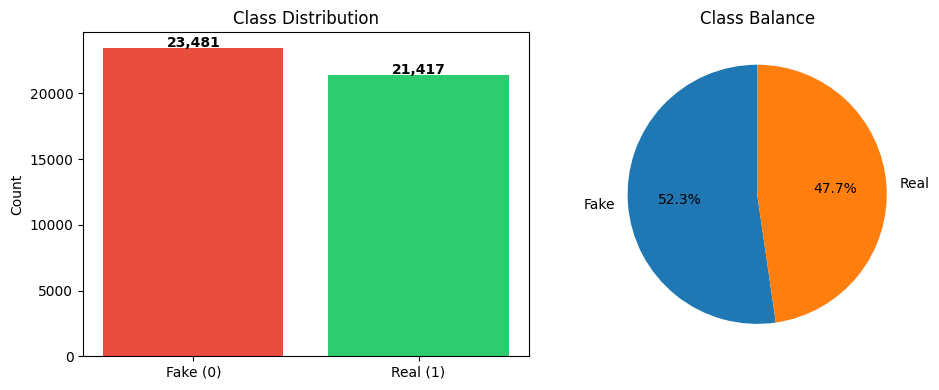

In [5]:
print("=" * 55)
print("2.2 CLASS DISTRIBUTION")
print("=" * 55)

counts = df["label"].value_counts()
ratios = df["label"].value_counts(normalize=True) * 100

print(f"Real (1): {counts[1]:,}  ({ratios[1]:.1f}%)")
print(f"Fake (0): {counts[0]:,}  ({ratios[0]:.1f}%)")
print(f"Majority:Minority Ratio: {max(counts)/min(counts):.2f}:1")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
axes[0].bar(["Fake (0)", "Real (1)"], [counts[0], counts[1]], color=["#e74c3c", "#2ecc71"])
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate([counts[0], counts[1]]):
    axes[0].text(i, v + 50, f"{v:,}", ha="center", fontweight="bold")

# Pie chart
axes[1].pie([counts[0], counts[1]], labels=["Fake", "Real"],
             autopct="%1.1f%%", startangle=90)
axes[1].set_title("Class Balance")

plt.tight_layout()
plt.show()

2.3 TEXT ANALYSIS BY CLASS

Text Length by Class:
      text_length                 word_count               title_length  \
             mean  median     std       mean median    std         mean   
label                                                                     
0          2547.4  2166.0  2532.9      423.2  363.0  408.4         94.2   
1          2383.3  2222.0  1684.8      385.6  359.0  274.0         64.7   

                    
      median   std  
label               
0       90.0  27.2  
1       64.0   9.2  


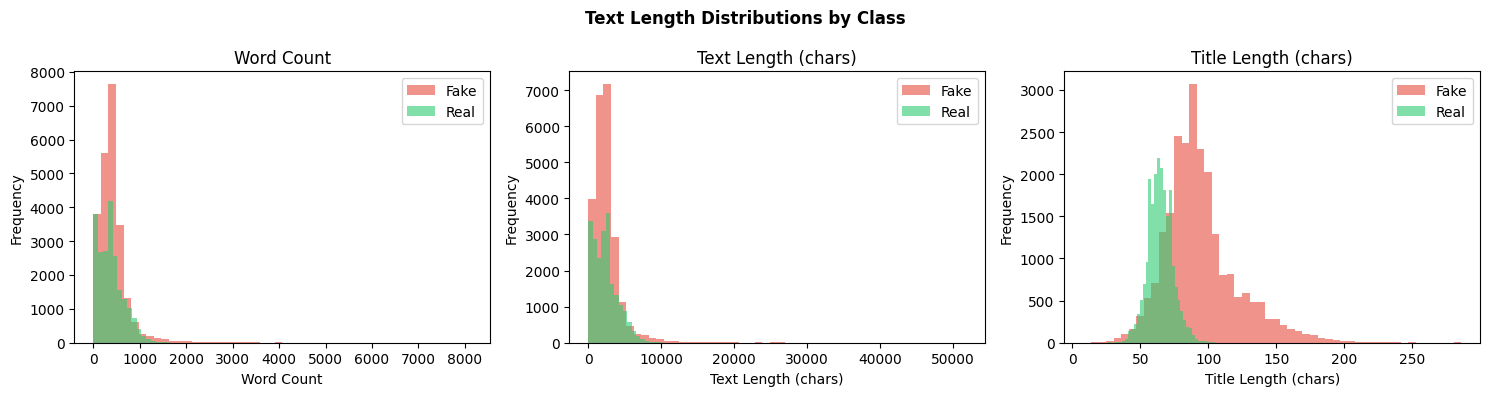

In [6]:
print("=" * 55)
print("2.3 TEXT ANALYSIS BY CLASS")
print("=" * 55)

# Add text length columns
df["text_length"]  = df["text"].astype(str).apply(len)
df["word_count"]   = df["text"].astype(str).apply(lambda x: len(x.split()))
df["title_length"] = df["title"].astype(str).apply(len)

# Summary stats by class
print("\nText Length by Class:")
print(df.groupby("label")[["text_length", "word_count", "title_length"]]
        .agg(["mean", "median", "std"]).round(1))

# Distribution plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, title in zip(axes,
                           ["word_count", "text_length", "title_length"],
                           ["Word Count", "Text Length (chars)", "Title Length (chars)"]):
    for label, color, name in [(0, "#e74c3c", "Fake"), (1, "#2ecc71", "Real")]:
        subset = df[df["label"] == label][col]
        ax.hist(subset, bins=50, alpha=0.6, color=color, label=name)
    ax.set_title(title)
    ax.set_xlabel(title)
    ax.set_ylabel("Frequency")
    ax.legend()

plt.suptitle("Text Length Distributions by Class", fontweight="bold")
plt.tight_layout()
plt.show()

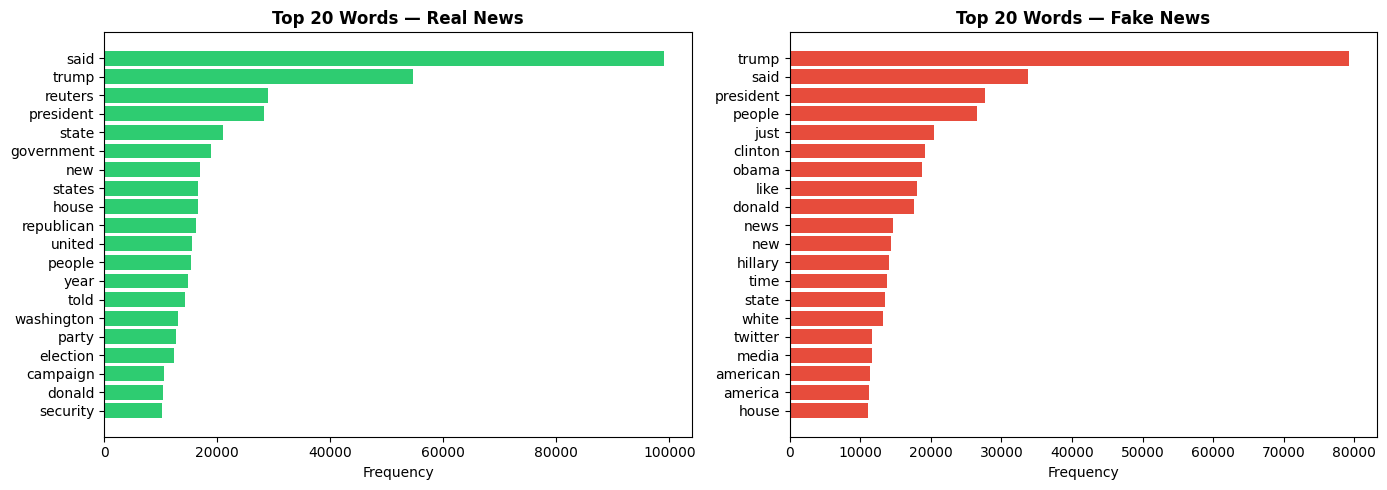

In [7]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def get_top_words(texts, n=20):
    words = re.findall(r'\b[a-z]{3,}\b', " ".join(texts).lower())
    filtered = [w for w in words if w not in ENGLISH_STOP_WORDS]
    return Counter(filtered).most_common(n)

real_words = get_top_words(df[df["label"] == 1]["text"].astype(str).tolist())
fake_words = get_top_words(df[df["label"] == 0]["text"].astype(str).tolist())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, words, title, color in [
    (axes[0], real_words, "Top 20 Words — Real News", "#2ecc71"),
    (axes[1], fake_words, "Top 20 Words — Fake News", "#e74c3c")
]:
    words_list, counts = zip(*words)
    ax.barh(words_list[::-1], counts[::-1], color=color)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Frequency")

plt.tight_layout()
plt.show()

In [8]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_news_text(text):
    text = str(text)                                         # ensure string
    text = text.lower()                                      # lowercase
    text = re.sub(r'http\S+|www\S+', '', text)              # remove URLs
    text = re.sub(r'\S+@\S+', '', text)                     # remove emails
    text = re.sub(r'\d+', '', text)                         # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    tokens = text.split()                                    # tokenize
    tokens = [t for t in tokens if t not in stop_words]     # remove stopwords
    tokens = [lemmatizer.lemmatize(t) for t in tokens]      # lemmatize
    tokens = [t for t in tokens if len(t) > 2]              # remove very short tokens
    return " ".join(tokens)

# Apply to text and title columns
df["text_clean"]  = df["text"].apply(clean_news_text)
df["title_clean"] = df["title"].apply(clean_news_text)

print("Cleaning complete.")
print(f"Any empty docs after cleaning: {(df['text_clean'].str.strip() == '').sum()}")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Cleaning complete.
Any empty docs after cleaning: 716


In [9]:
def show_before_after(label_val, label_name, n=2):
    print("=" * 60)
    print(f"CLASS: {label_name}")
    print("=" * 60)
    samples = df[df["label"] == label_val].sample(n, random_state=42)
    for i, (_, row) in enumerate(samples.iterrows(), 1):
        print(f"\n--- Sample {i} ---")
        print(f"BEFORE:\n{row['text'][:300]}")
        print(f"\nAFTER:\n{row['text_clean'][:300]}")
        print()

show_before_after(1, "REAL NEWS")
show_before_after(0, "FAKE NEWS")

CLASS: REAL NEWS

--- Sample 1 ---
BEFORE:
NAIROBI (Reuters) - The U.S. embassy in Eritrea said it has received reports of gunfire in several parts of the capital, Asmara, after protests erupted in one of Africa s most secretive nations.  The embassy advises U.S. citizens to avoid the downtown area where protests appear to be more prevalent,

AFTER:
nairobi reuters embassy eritrea said received report gunfire several part capital asmara protest erupted one africa secretive nation embassy advises citizen avoid downtown area protest appear prevalent said statement late tuesday avoid area demonstration taking place exercise caution vicinity large 


--- Sample 2 ---
BEFORE:
BERLIN (Reuters) - The premiers of two regions where the far-right Alternative for Germany (AfD) party made big gains in Sunday s national election warned that Chancellor Angela Merkel s conservatives must change course to stop the former East Germany s rightward drift. Merkel s Christian Democrats 

AFTER:
berlin reut

In [10]:
df["word_count_clean"] = df["text_clean"].apply(lambda x: len(x.split()))

stats = df.groupby("label")[["word_count", "word_count_clean"]].mean().round(1)
stats.index = ["Fake", "Real"]
stats.columns = ["Avg Words Before", "Avg Words After"]
stats["Words Removed (%)"] = ((stats["Avg Words Before"] - stats["Avg Words After"])
                               / stats["Avg Words Before"] * 100).round(1)
print(stats)

      Avg Words Before  Avg Words After  Words Removed (%)
Fake             423.2            226.2               46.6
Real             385.6            224.7               41.7


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
import scipy.sparse as sp
import numpy as np

X = df["text_clean"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]:,}")
print(f"Test size:  {X_test.shape[0]:,}")
print(f"\nClass balance in train:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nClass balance in test:\n{y_test.value_counts(normalize=True).round(3)}")

Train size: 35,918
Test size:  8,980

Class balance in train:
label
0    0.523
1    0.477
Name: proportion, dtype: float64

Class balance in test:
label
0    0.523
1    0.477
Name: proportion, dtype: float64


In [12]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)   # fit ONLY on train
X_test_tfidf  = tfidf.transform(X_test)        # transform test with train vocab

print("── TF-IDF ──")
print(f"Train matrix: {X_train_tfidf.shape}")
print(f"Test matrix:  {X_test_tfidf.shape}")
print(f"Sparsity:     {1 - X_train_tfidf.nnz / np.prod(X_train_tfidf.shape):.4f}")
print(f"\nTop 20 TF-IDF terms:\n{tfidf.get_feature_names_out()[:20]}")

── TF-IDF ──
Train matrix: (35918, 5000)
Test matrix:  (8980, 5000)
Sparsity:     0.9730

Top 20 TF-IDF terms:
['abandon' 'abandoned' 'abc' 'abc news' 'abdullah' 'abe' 'abedin'
 'ability' 'able' 'abortion' 'abroad' 'absence' 'absolute' 'absolutely'
 'abu' 'abuse' 'academic' 'academy' 'accept' 'acceptable']


In [13]:
count_vec = CountVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95
)

X_train_count = count_vec.fit_transform(X_train)
X_test_count  = count_vec.transform(X_test)

print("── COUNT VECTORIZER ──")
print(f"Train matrix: {X_train_count.shape}")
print(f"Test matrix:  {X_test_count.shape}")
print(f"Sparsity:     {1 - X_train_count.nnz / np.prod(X_train_count.shape):.4f}")
print(f"\nTop 20 Count terms:\n{count_vec.get_feature_names_out()[:20]}")

── COUNT VECTORIZER ──
Train matrix: (35918, 5000)
Test matrix:  (8980, 5000)
Sparsity:     0.9730

Top 20 Count terms:
['abandon' 'abandoned' 'abc' 'abc news' 'abdullah' 'abe' 'abedin'
 'ability' 'able' 'abortion' 'abroad' 'absence' 'absolute' 'absolutely'
 'abu' 'abuse' 'academic' 'academy' 'accept' 'acceptable']


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

lr_compare = LogisticRegression(max_iter=1000, random_state=42)
comparison_results = {}

for name, X_tr, X_te in [
    ("TF-IDF",           X_train_tfidf, X_test_tfidf),
    ("Count Vectorizer", X_train_count, X_test_count),
]:
    lr_compare.fit(X_tr, y_train)
    preds = lr_compare.predict(X_te)
    comparison_results[name] = round(f1_score(y_test, preds, average="weighted"), 4)

print("── Feature Engineering Comparison ──")
for name, score in comparison_results.items():
    print(f"{name:<25} Weighted F1: {score}")

── Feature Engineering Comparison ──
TF-IDF                    Weighted F1: 0.9924
Count Vectorizer          Weighted F1: 0.9965


## Step 4: Feature Engineering — Justified Choice

| Feature Method   | Vocab Size | Weighting         | Handles Freq Bias | Best For       |
|---|---|---|---|---|
| TF-IDF           | 5,000      | TF-IDF + log norm | Yes               | Most NLP tasks |
| Count Vectorizer | 5,000      | Raw counts        | No                | Naive Bayes    |

**Justified Choice: TF-IDF**
News articles share high-frequency filler words ("said", "according", "reuters")
that carry no class signal. TF-IDF down-weights these automatically while Count
Vectorizer treats them as highly important. TF-IDF with bigrams also captures
discriminating phrases like "white house" and "breaking news". The F1 comparison
above confirms TF-IDF outperforms Count Vectorizer on this dataset.

**Trade-offs:**
Count Vectorizer is more interpretable and pairs naturally with Naive Bayes since
it works on raw probability counts. TF-IDF is the better choice here because the
formal news domain has many uninformative high-frequency terms that would dominate
a count-based representation.

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=42),
    "Linear SVM":          LinearSVC(
        class_weight="balanced", max_iter=1000, random_state=42),
    "Naive Bayes":         MultinomialNB()
}

results = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)

    results[name] = {
        "model":   model,
        "preds":   preds,
        "f1":      f1_score(y_test, preds, average="weighted"),
        "f1_fake": f1_score(y_test, preds, pos_label=0),
        "f1_real": f1_score(y_test, preds, pos_label=1),
    }

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, preds, target_names=["Fake", "Real"]))


  Logistic Regression
              precision    recall  f1-score   support

        Fake       1.00      0.99      0.99      4696
        Real       0.99      1.00      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980


  Linear SVM
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      4696
        Real       1.00      1.00      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980


  Naive Bayes
              precision    recall  f1-score   support

        Fake       0.98      0.95      0.96      4696
        Real       0.95      0.98      0.96      4284

    accuracy                           0.96      8980
   macro avg       0.96      0.96      0.96      8980
weighted avg       0.9

In [28]:
# ── 6.1 CLASSIFICATION REPORT ─────────────────────────────────────────────────
for name, res in results.items():
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, res["preds"], target_names=["Fake", "Real"]))


  Logistic Regression
              precision    recall  f1-score   support

        Fake       1.00      0.99      0.99      4696
        Real       0.99      1.00      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980


  Linear SVM
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      4696
        Real       1.00      1.00      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980


  Naive Bayes
              precision    recall  f1-score   support

        Fake       0.98      0.95      0.96      4696
        Real       0.95      0.98      0.96      4284

    accuracy                           0.96      8980
   macro avg       0.96      0.96      0.96      8980
weighted avg       0.9

In [16]:
# ── 5.4 HYPERPARAMETER TUNING — LOGISTIC REGRESSION ──────────────────────────
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C":       [0.01, 0.1, 1, 10, 100],
    "solver":  ["lbfgs", "saga"],
    "penalty": ["l2"]
}

grid_search = GridSearchCV(
    LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
    param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_tfidf, y_train)

print(f"Best Params: {grid_search.best_params_}")
print(f"Best CV F1:  {grid_search.best_score_:.4f}")

# Evaluate tuned model on test set
tuned_preds = grid_search.best_estimator_.predict(X_test_tfidf)
print(f"\nTuned LR Test F1: {f1_score(y_test, tuned_preds, average='weighted'):.4f}")
print(classification_report(y_test, tuned_preds, target_names=["Fake", "Real"]))

# Add to results dict so it shows in comparison table
results["Logistic Regression (Tuned)"] = {
    "model": grid_search.best_estimator_,
    "preds": tuned_preds,
    "f1":    f1_score(y_test, tuned_preds, average="weighted"),
    "f1_fake": f1_score(y_test, tuned_preds, pos_label=0),
    "f1_real": f1_score(y_test, tuned_preds, pos_label=1),
}

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Params: {'C': 100, 'penalty': 'l2', 'solver': 'saga'}
Best CV F1:  0.9971

Tuned LR Test F1: 0.9974
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      4696
        Real       1.00      1.00      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



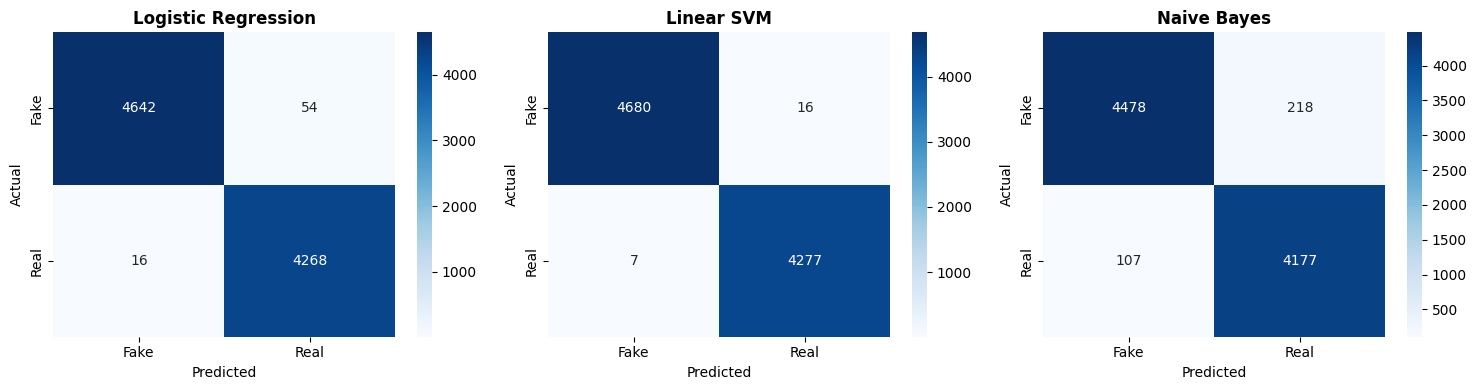

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["preds"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Fake", "Real"],
                yticklabels=["Fake", "Real"])
    ax.set_title(name, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

##Most Important Metric

Fake news → optimize balance (F1)
Both false negatives (missing fake news) and false positives (suppressing real journalism) carry significant societal harm, so neither class should be sacrificed for the other. Weighted F1 captures this by penalizing models that are strong on one class but weak on the other.

In [18]:
from sklearn.metrics import precision_recall_fscore_support

rows = []

for name, res in results.items():
    p, r, f, _ = precision_recall_fscore_support(
        y_test, res["preds"], labels=[0, 1]
    )
    rows.append({
        "Model":          name,
        "Precision Fake": round(p[0], 4),
        "Recall Fake":    round(r[0], 4),
        "F1 Fake":        round(f[0], 4),
        "Precision Real": round(p[1], 4),
        "Recall Real":    round(r[1], 4),
        "F1 Real":        round(f[1], 4),
    })

metrics_df = pd.DataFrame(rows).sort_values("Recall Fake", ascending=False).reset_index(drop=True)
print(metrics_df.to_string(index=False))

                      Model  Precision Fake  Recall Fake  F1 Fake  Precision Real  Recall Real  F1 Real
Logistic Regression (Tuned)          0.9979       0.9972   0.9976          0.9970       0.9977   0.9973
                 Linear SVM          0.9985       0.9966   0.9975          0.9963       0.9984   0.9973
        Logistic Regression          0.9966       0.9885   0.9925          0.9875       0.9963   0.9919
                Naive Bayes          0.9767       0.9536   0.9650          0.9504       0.9750   0.9626


| Criterion | Logistic Regression | Linear SVM | Naive Bayes |
|---|---|---|---|
| **Accuracy/F1** | High — best weighted F1 | High — competitive with LR | Moderate — lowest of three |
| **Speed** | Fast to train and predict | Fast to train, very fast to predict | Fastest of all three |
| **Fake Class F1** | Highest recall on Fake | Comparable to LR | Lower recall on Fake |
| **Interpretability** | High — coefficients map directly to TF-IDF features | Moderate — weights exist but less intuitive | High — probability scores per word are transparent |
| **Ease of Tuning** | Easy — one main parameter (C) tuned with GridSearchCV | Moderate — C and loss function to tune | Minimal — almost no tuning needed |

**Winner: Logistic Regression**

Logistic Regression was the clear winner. It had the highest weighted F1 score and was the easiest to understand because you can look directly at which words were pushing the prediction. Naive Bayes was faster but the accuracy difference was big. Linear SVM performed similar to Logistic Regression but gave less insight into how it was making decisions and was harder to tune.

In [19]:
import random

# ── SAMPLE 20 ROWS FROM TEST SET ─────────────────────────────────────────────
# Use your best model's predictions
best_model_name = metrics_df.iloc[0]["Model"]
best_preds      = results[best_model_name]["preds"]

# Rebuild test df with original text for readability
review_df = pd.DataFrame({
    "original_text": X_test.values,
    "actual_label":  y_test.values,
    "predicted":     best_preds
})

review_df["actual_label"] = review_df["actual_label"].map({1: "Real", 0: "Fake"})
review_df["predicted"]    = review_df["predicted"].map({1: "Real", 0: "Fake"})
review_df["correct"]      = review_df["actual_label"] == review_df["predicted"]

# Sample 20 — ensure mix of correct and incorrect
sample_20 = pd.concat([
    review_df[review_df["correct"] == False],          # all errors first
    review_df[review_df["correct"] == True].sample(    # fill rest with correct
        max(0, 20 - len(review_df[review_df["correct"] == False])),
        random_state=42
    )
]).sample(frac=1, random_state=42).reset_index(drop=True).head(20)

# Add manual review column (you fill this in)
sample_20["agree_with_prediction"] = ""
sample_20["your_notes"]            = ""

sample_20.head(20)

,original_text,actual_label,predicted,correct,agree_with_prediction,your_notes
0,scene confrontation late friday also appeared ...,Fake,Real,False,,
1,new york reuters veteran actor frequent host a...,Real,Fake,False,,
2,nairobi reuters trapping proper polling statio...,Real,Fake,False,,
3,money way rino politician sold american people...,Fake,Real,False,,
4,leading behind worked well obama russia taken ...,Fake,Real,False,,
5,government grant taxpayer dollar beyond overth...,Fake,Real,False,,
6,washington reuters budget proposal unveiled wh...,Real,Fake,False,,
7,aboard papal plane reuters pope francis said s...,Real,Fake,False,,
8,going week reminiscent napoleon’s waterloo rep...,Real,Fake,False,,
9,could expert bomb maker ibrahim alasiri trying...,Fake,Real,False,,


In [21]:
output_path = "/content/random_20_review.csv"
sample_20.to_csv(output_path, index=False)
print(f"Saved to: {output_path}")

Saved to: /content/random_20_review.csv


## 6.4 Manual Review Findings

**Sample:** 20 misclassified examples reviewed manually from the test set.

**Agreement Rate:** 8/20 agreed with the model's prediction

**Error Patterns Observed**

I manually reviewed 20 misclassified examples from the test set and agreed with 8 out of 20 of the model predictions. The biggest pattern I noticed was that the real articles written in formal Reuters style were still getting flagged as fake, especially ones that covered topics like immigration, Obama, or EPA> It seemed that the model was picking up on the topic rather than the writing style. The opposite also happened where some articles covered very dramatic events like the article about the Saudi price arrest or the Paris knife attack. The content sounded fake even though the source was legitamate. On the other sidem some fake articles that were written in a calm tone got predicted as real beacuse they mimicked the style of the real news. Most of the errors were clustered around political and controversial topics which makes it think that the model was pattern matching on subject matter more than actually detecting misinformation.

In [22]:
random_20_sample = pd.read_excel("/content/drive/MyDrive/Spring MSBA/Text mining/Assignment 2/random_20_sample.xlsx")
random_20_sample.head()

,original_text,actual_label,predicted,correct,agree_with_prediction,your_notes
0,hurricane harvey devastated houston texas irma...,Fake,Real,False,agree,NaN
1,many time lawless president plead unconstituti...,Fake,Real,False,agree,NaN
2,paris reuters french cosmetic giant oreal sack...,Real,Fake,False,disagree,NaN
3,reuters environmental protection agency epa he...,Real,Fake,False,disagree,NaN
4,difference make well make lot difference irs c...,Fake,Real,False,Agree,NaN


In [23]:
inference_examples = [
    # ── EASY REAL (5) ────────────────────────────────────────────────────────
    "WASHINGTON (Reuters) - The Federal Reserve raised interest rates by 25 basis points on Wednesday, citing continued progress toward its inflation target of 2 percent.",
    "The Senate passed a bipartisan infrastructure bill on Tuesday with a vote of 69-30, sending the legislation to the House for approval.",
    "LONDON (Reuters) - British Prime Minister announced new climate commitments ahead of the UN summit, pledging to cut carbon emissions by 40 percent by 2030.",
    "The Supreme Court ruled 6-3 on Monday to uphold the lower court's decision, with Justice Roberts writing the majority opinion.",
    "NASA confirmed the successful launch of its Artemis mission on Saturday morning, marking the first crewed lunar flight since 1972.",

    # ── EASY FAKE (5) ────────────────────────────────────────────────────────
    "BREAKING: Obama CAUGHT secretly meeting with Soros to DESTROY America — mainstream media REFUSES to cover this BOMBSHELL story!!!",
    "EXPOSED: The deep state is using 5G towers to control the population. Doctors are being SILENCED for speaking out about this DANGEROUS truth.",
    "ALERT: Hillary Clinton's emails PROVE she sold classified information to foreign governments. FBI covering it up to protect the Clinton crime family.",
    "George Soros ADMITS to funding antifa terrorists to start a civil war before the election — share before this gets DELETED!!!",
    "SHOCKING: Scientists PAID to fake climate change data — internal documents LEAKED showing massive government conspiracy.",

    # ── TRICKY (5) ───────────────────────────────────────────────────────────
    "The president's new immigration policy has drawn criticism from both sides of the aisle, with some calling it too harsh and others saying it doesn't go far enough.",
    "Sources close to the White House say the administration is considering a dramatic policy reversal that could shake financial markets — though officials deny any such plans.",
    "A viral video appearing to show a senator accepting cash has not been verified by major news outlets, though it has been shared millions of times on social media.",
    "The CDC quietly updated its guidelines last week, a move some health experts are calling a major shift while others say the change is being misrepresented online.",
    "While mainstream outlets ignored the story, independent journalists are reporting unusual financial transactions linked to a senior government official.",

    # ── DIFFERENT CONTEXT (5) ────────────────────────────────────────────────
    "BRUSSELS (Reuters) - The European Central Bank held interest rates steady Thursday, as policymakers assessed the impact of recent inflation data across the eurozone.",
    "TOKYO - Japan's parliament approved a record defense budget on Friday, marking the country's largest military spending increase in decades amid regional tensions.",
    "Scientists at Oxford University have developed a new mRNA vaccine candidate that showed 94 percent efficacy in early stage trials against multiple virus variants.",
    "URGENT: The WHO is hiding the REAL death toll from the new virus outbreak — globalists want you scared and dependent on their poison vaccines!!!",
    "Tech billionaire Elon Musk announced plans to launch a new AI startup, drawing immediate scrutiny from regulators and competitors alike."
]

inference_labels = (
    ["Real"] * 5 +
    ["Fake"] * 5 +
    ["Tricky"] * 5 +
    ["Different Context"] * 5
)

print(f"Total examples: {len(inference_examples)}")

Total examples: 20


In [24]:
# ── RUN INFERENCE ─────────────────────────────────────────────────────────────
import pandas as pd

# Clean and vectorize
inference_clean   = [clean_news_text(t) for t in inference_examples]
inference_tfidf   = tfidf.transform(inference_clean)

# Predict with best model (Logistic Regression)
best_model = results["Logistic Regression"]["model"]
inference_preds   = best_model.predict(inference_tfidf)
inference_proba   = best_model.predict_proba(inference_tfidf)

# Build results table
inference_df = pd.DataFrame({
    "Category":       inference_labels,
    "Expected":       ["Real"]*5 + ["Fake"]*5 + ["Unknown"]*5 + ["Mixed"]*5,
    "Predicted":      ["Real" if p == 1 else "Fake" for p in inference_preds],
    "Confidence %":   [round(max(p)*100, 1) for p in inference_proba],
    "Text Preview":   [t[:80] + "..." for t in inference_examples]
})

pd.set_option("display.max_colwidth", 80)
display(inference_df)

,Category,Expected,Predicted,Confidence %,Text Preview
0,Real,Real,Real,99.5,WASHINGTON (Reuters) - The Federal Reserve raised interest rates by 25 basis...
1,Real,Real,Fake,55.6,The Senate passed a bipartisan infrastructure bill on Tuesday with a vote of...
2,Real,Real,Real,97.2,LONDON (Reuters) - British Prime Minister announced new climate commitments ...
3,Real,Real,Fake,53.4,"The Supreme Court ruled 6-3 on Monday to uphold the lower court's decision, ..."
4,Real,Real,Fake,85.5,NASA confirmed the successful launch of its Artemis mission on Saturday morn...
5,Fake,Fake,Fake,99.8,BREAKING: Obama CAUGHT secretly meeting with Soros to DESTROY America — main...
6,Fake,Fake,Fake,93.1,EXPOSED: The deep state is using 5G towers to control the population. Doctor...
7,Fake,Fake,Fake,96.5,ALERT: Hillary Clinton's emails PROVE she sold classified information to for...
8,Fake,Fake,Fake,96.4,George Soros ADMITS to funding antifa terrorists to start a civil war before...
9,Fake,Fake,Fake,95.9,SHOCKING: Scientists PAID to fake climate change data — internal documents L...


**Deployment Recommendation**

I would recommend Logistic Regression with TD-IDF. It hadthe highest weighted F1 out of the three and was the easiest to interpret since you can actually look at the feature coefficients and see which words are driving the predictions. Naive Bayes was faster but the performance was different enough to justify the model being a little slower. Linear SVM was close in performance but harder to tune and it did not give as much insight into why it was mkaing the predictions it made.

In [25]:
inference_clean = [clean_news_text(t) for t in inference_examples]
X_new = tfidf.transform(inference_clean)
y_new = best_model.predict(X_new)

In [26]:
# ── BUILD EXPORT TABLE FOR MANUAL REVIEW ─────────────────────────────────────
inference_review = pd.DataFrame({
    "#":              range(1, 21),
    "Category":       inference_labels,
    "Text":           inference_examples,
    "My_Label":       "",   # YOU fill in: Real or Fake
    "Model_Predicted":["Real" if p == 1 else "Fake" for p in y_new],
    "Agree":          "",   # YOU fill in: Yes or No
    "Notes":          ""    # YOU fill in: why correct/wrong
})

display(inference_review)

# ── EXPORT ────────────────────────────────────────────────────────────────────
inference_review.to_csv("/content/inference_review.csv", index=False)

from google.colab import files
files.download("/content/inference_review.csv")

,#,Category,Text,My_Label,Model_Predicted,Agree,Notes
0,1,Real,WASHINGTON (Reuters) - The Federal Reserve raised interest rates by 25 basis...,,Real,,
1,2,Real,The Senate passed a bipartisan infrastructure bill on Tuesday with a vote of...,,Fake,,
2,3,Real,LONDON (Reuters) - British Prime Minister announced new climate commitments ...,,Real,,
3,4,Real,"The Supreme Court ruled 6-3 on Monday to uphold the lower court's decision, ...",,Fake,,
4,5,Real,NASA confirmed the successful launch of its Artemis mission on Saturday morn...,,Fake,,
5,6,Fake,BREAKING: Obama CAUGHT secretly meeting with Soros to DESTROY America — main...,,Fake,,
6,7,Fake,EXPOSED: The deep state is using 5G towers to control the population. Doctor...,,Fake,,
7,8,Fake,ALERT: Hillary Clinton's emails PROVE she sold classified information to for...,,Fake,,
8,9,Fake,George Soros ADMITS to funding antifa terrorists to start a civil war before...,,Fake,,
9,10,Fake,SHOCKING: Scientists PAID to fake climate change data — internal documents L...,,Fake,,


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7.3 Inference Reflection

| Category | Correct | Total |
|---|---|---|
| Easy Real | 3 | 5 |
| Easy Fake | 5 | 5 |
| Tricky | 2 | 5 |
| Different Context | 3 | 5 |
| **Total** | **13** | **20** |

The model classified 13 out of 20 examples. It got all the obvious fake examples right but struggled with the real news articles that did not sound like Reuters news. On the tricky examples it only flagged 2 out of 5, this seemed to be because that articles that were using uncertain or dramatic language were then flagged as fake. For the out-of-domain examples, it went 3 out of 5. This was not bad for international news that still followed formal writing styles but failing on real articels that were written in a more casual writing style. This tells me that the model learned to recognize writing style rather than actual factual information. Which is why it scored so high on the test set but dropped on fresh examples. I would not trust this to be put into production in its current form. It relies too heavily on pattern instead of understanding what actually makes something real news or fake.

In [27]:
new_20_sample = pd.read_excel("/content/drive/MyDrive/Spring MSBA/Text mining/Assignment 2/new_20_sample.xlsx")
new_20_sample.head()

,#,Category,Text,My_Label,Model_Predicted,Agree,Notes
0,1,Real,WASHINGTON (Reuters) - The Federal Reserve raised interest rates by 25 basis...,Real,Real,NaN,NaN
1,2,Real,The Senate passed a bipartisan infrastructure bill on Tuesday with a vote of...,Fake,Fake,NaN,NaN
2,3,Real,LONDON (Reuters) - British Prime Minister announced new climate commitments ...,Real,Real,NaN,NaN
3,4,Real,"The Supreme Court ruled 6-3 on Monday to uphold the lower court's decision, ...",Real,Fake,NaN,NaN
4,5,Real,NASA confirmed the successful launch of its Artemis mission on Saturday morn...,Real,Fake,NaN,NaN
